In [7]:
# !pip install qiskit qiskit-aer matplotlib

import random
import hashlib
import matplotlib.pyplot as plt

# -----------------------------------------
# SETTINGS
# -----------------------------------------
N = 1000
RUNS = 50
THEORETICAL_KEY_RATE = 0.25

# -----------------------------------------
# GENERATE RANDOM BITS
# -----------------------------------------
def generate_bits(n):
    return [random.randint(0, 1) for _ in range(n)]

# -----------------------------------------
# B92 PROTOCOL
# -----------------------------------------
def b92_protocol(alice_bits, attack=False):
    bob_key = []
    indices = []

    for i, alice_bit in enumerate(alice_bits):

        # ----- EVE ATTACK -----
        if attack:
            eve_basis = random.choice(['Z', 'X'])

            if eve_basis == 'Z':
                if alice_bit == 1:
                    eve_measured_bit = 1
                else:
                    eve_measured_bit = random.randint(0, 1)
            else:
                if alice_bit == 0:
                    eve_measured_bit = 0
                else:
                    eve_measured_bit = random.randint(0, 1)

            sent_bit = eve_measured_bit
        else:
            sent_bit = alice_bit

        # ----- BOB -----
        bob_basis = random.choice(['Z', 'X'])

        if bob_basis == 'Z':
            if sent_bit == 1 and random.random() < 0.5:
                bob_key.append(1)
                indices.append(i)
        else:
            if sent_bit == 0 and random.random() < 0.5:
                bob_key.append(0)
                indices.append(i)

    return bob_key, indices

# -----------------------------------------
# QBER
# -----------------------------------------
def compute_qber(alice_bits, bob_key, indices):
    if len(bob_key) == 0:
        return 0.0

    errors = sum(
        1 for i, idx in enumerate(indices)
        if bob_key[i] != alice_bits[idx]
    )
    return errors / len(bob_key)

# -----------------------------------------
# PRIVACY AMPLIFICATION
# -----------------------------------------
def privacy_amplification(key):
    key_str = ''.join(map(str, key))
    hashed = hashlib.sha256(key_str.encode()).hexdigest()
    return [int(b) for b in bin(int(hashed, 16))[2:].zfill(256)]

# -----------------------------------------
# USER MODE
# -----------------------------------------
def run_user():
    print("\n===== USER MODE =====")

    # 🔧 FIX: force proper input read
    attack_input = input("Simulate Eve attack? (y/n): ")
    attack = attack_input.strip().lower() == 'y'

    alice_bits = generate_bits(N)
    bob_key, indices = b92_protocol(alice_bits, attack=attack)

    print(f"Qubits transmitted   : {N}")
    print(f"Sifted key length    : {len(bob_key)} ({len(bob_key)/N*100:.1f}%)")

    if len(bob_key) < 10:
        print("Key too short.")
        return

    qber = compute_qber(alice_bits, bob_key, indices)
    print(f"QBER                 : {qber:.4f}")

    if qber >= 0.11:
        print("❌ Channel compromised. Abort.")
        return

    print("✅ Channel secure.")

    secure_key = privacy_amplification(bob_key)
    print(f"Secure key (first 32 bits): {secure_key[:32]}")
    print("===========================\n")

# -----------------------------------------
# ANALYSIS MODE
# -----------------------------------------
def run_analysis():
    print("\n===== ANALYSIS MODE =====")

    eff_attack, eff_no = [], []
    qber_attack, qber_no = [], []

    for _ in range(RUNS):
        alice_bits = generate_bits(N)

        key_a, idx_a = b92_protocol(alice_bits, attack=True)
        eff_attack.append(len(key_a) / N)
        qber_attack.append(compute_qber(alice_bits, key_a, idx_a))

        key_n, idx_n = b92_protocol(alice_bits, attack=False)
        eff_no.append(len(key_n) / N)
        qber_no.append(compute_qber(alice_bits, key_n, idx_n))

    runs_x = list(range(1, RUNS + 1))

    plt.figure()
    plt.plot(runs_x, eff_attack, label="Attack")
    plt.plot(runs_x, eff_no, label="No Attack")
    plt.axhline(y=THEORETICAL_KEY_RATE, linestyle='--', label="Theory 25%")
    plt.xlabel("Run")
    plt.ylabel("Efficiency")
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure()
    plt.plot(runs_x, qber_attack, label="Attack")
    plt.plot(runs_x, qber_no, label="No Attack")
    plt.axhline(y=0.25, linestyle='--', label="Attack ~25%")
    plt.axhline(y=0.11, linestyle='--', label="Threshold 11%")
    plt.xlabel("Run")
    plt.ylabel("QBER")
    plt.legend()
    plt.grid()
    plt.show()

    print("\n===== SUMMARY =====")
    print(f"Avg Eff (No Attack): {sum(eff_no)/len(eff_no):.4f}")
    print(f"Avg Eff (Attack)   : {sum(eff_attack)/len(eff_attack):.4f}")
    print(f"Avg QBER (No Attack): {sum(qber_no)/len(qber_no):.4f}")
    print(f"Avg QBER (Attack)   : {sum(qber_attack)/len(qber_attack):.4f}")

# -----------------------------------------
# MAIN (CONTROL MODE FIXED)
# -----------------------------------------
print("B92 QKD Simulator")
print("=================")

# 🔧 CRITICAL FIX: force proper input read
mode = input("Select mode (1 = User, 2 = Analysis): ")

if mode.strip() == "1":
    run_user()
elif mode.strip() == "2":
    run_analysis()
else:
    print("Invalid input. Enter 1 or 2.")

B92 QKD Simulator
Select mode (1 = User, 2 = Analysis): 1

===== USER MODE =====
Simulate Eve attack? (y/n): y
Qubits transmitted   : 1000
Sifted key length    : 237 (23.7%)
QBER                 : 0.2447
❌ Channel compromised. Abort.


Quantum Key Distribution Simulator (BB84 Final)
Mode (1 user / 2 analysis): 2

--- ANALYSIS MODE (BB84) ---


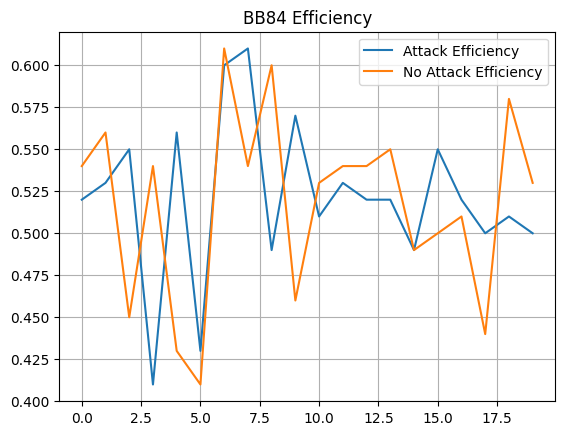

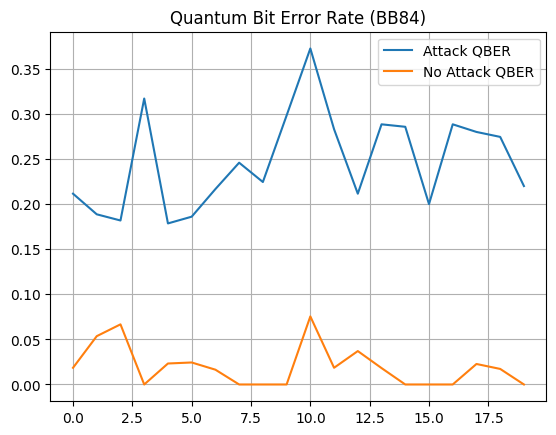

In [2]:
!pip install qiskit qiskit-aer matplotlib
import random
import hashlib
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# ================= SETTINGS =================
n = 100
RUNS = 20
NOISE_PROB = 0.02

# ================= CORE =================
def generate_bits(n):
    return [random.randint(0, 1) for _ in range(n)]

def generate_bases(n):
    return [random.choice(['Z', 'X']) for _ in range(n)]

# ================= ENCODE =================
def encode(bits, bases):
    qc = QuantumCircuit(n, n)
    for i in range(n):
        if bits[i] == 1:
            qc.x(i)
        if bases[i] == 'X':
            qc.h(i)
    return qc

# ================= MEASURE =================
def measure(qc, bases):
    for i in range(n):
        if bases[i] == 'X':
            qc.h(i)

    qc.measure(range(n), range(n))

    sim = AerSimulator()
    result = sim.run(qc, shots=1).result()
    counts = result.get_counts()

    return list(counts.keys())[0][::-1]

# ================= BB84 SIFT =================
def sift_key(a_bits, a_bases, b_bases, b_results):
    key = []
    indices = []

    for i in range(n):
        # Keep only when bases MATCH
        if a_bases[i] == b_bases[i]:
            key.append(int(b_results[i]))
            indices.append(i)

    return key, indices

# ================= NOISE =================
def apply_noise(bits):
    return [(b ^ 1 if random.random() < NOISE_PROB else b) for b in bits]

# ================= ATTACK (INTERCEPT-RESEND) =================
def eve(bits, bases):
    eve_bases = generate_bases(n)
    result = []

    for i in range(n):
        if eve_bases[i] == bases[i]:
            result.append(bits[i])
        else:
            result.append(random.randint(0, 1))

    return result

# ================= QBER =================
def compute_qber(a_bits, key, indices):
    if len(key) == 0:
        return 0

    errors = 0
    for i, idx in enumerate(indices):
        if key[i] != a_bits[idx]:
            errors += 1

    return errors / len(key)

# ================= PRIVACY =================
def privacy_amplification(key):
    key_str = ''.join(map(str, key))
    hashed = hashlib.sha256(key_str.encode()).hexdigest()
    return [int(b) for b in bin(int(hashed, 16))[2:].zfill(256)]

# ================= USER MODE =================
def run_user():
    print("\n--- USER MODE (BB84) ---")
    msg = input("Enter message: ")
    ATTACK = input("Attack? y/n: ") == 'y'

    bits = generate_bits(n)
    bases = generate_bases(n)

    transmitted = eve(bits, bases) if ATTACK else bits
    transmitted = apply_noise(transmitted)

    qc = encode(transmitted, bases)
    bob_bases = generate_bases(n)
    results = measure(qc, bob_bases)

    key, indices = sift_key(bits, bases, bob_bases, results)

    print("Key length:", len(key))

    if len(key) < 10:
        print("Weak key. Retry.")
        return

    qber_val = compute_qber(bits, key, indices)
    print("QBER:", round(qber_val, 4))

    final_key = privacy_amplification(key)

    # Encrypt / Decrypt
    msg_bits = [int(b) for c in msg for b in bin(ord(c))[2:].zfill(8)]
    enc = [(msg_bits[i] ^ final_key[i % len(final_key)]) for i in range(len(msg_bits))]
    dec = [(enc[i] ^ final_key[i % len(final_key)]) for i in range(len(enc))]

    text = ''.join(chr(int(''.join(map(str, dec[i:i+8])), 2)) for i in range(0, len(dec), 8))

    print("Decrypted:", text)

# ================= ANALYSIS =================
def run_analysis():
    print("\n--- ANALYSIS MODE (BB84) ---")

    eff_attack, eff_no = [], []
    qber_attack, qber_no = [], []

    for _ in range(RUNS):
        bits = generate_bits(n)
        bases = generate_bases(n)

        # WITH ATTACK
        t = apply_noise(eve(bits, bases))
        qc = encode(t, bases)
        bob_bases = generate_bases(n)
        res = measure(qc, bob_bases)
        key, idx = sift_key(bits, bases, bob_bases, res)

        eff_attack.append(len(key)/n)
        qber_attack.append(compute_qber(bits, key, idx))

        # WITHOUT ATTACK
        t = apply_noise(bits)
        qc = encode(t, bases)
        bob_bases = generate_bases(n)
        res = measure(qc, bob_bases)
        key, idx = sift_key(bits, bases, bob_bases, res)

        eff_no.append(len(key)/n)
        qber_no.append(compute_qber(bits, key, idx))

    # ===== PLOTS =====
    plt.figure()
    plt.plot(eff_attack, label="Attack Efficiency")
    plt.plot(eff_no, label="No Attack Efficiency")
    plt.title("BB84 Efficiency")
    plt.legend()
    plt.grid()

    plt.figure()
    plt.plot(qber_attack, label="Attack QBER")
    plt.plot(qber_no, label="No Attack QBER")
    plt.title("Quantum Bit Error Rate (BB84)")
    plt.legend()
    plt.grid()

    plt.show()

# ================= MAIN =================
if __name__ == "__main__":
    print("Quantum Key Distribution Simulator (BB84 Final)")

    mode = input("Mode (1 user / 2 analysis): ")

    if mode == "1":
        run_user()
    else:
        run_analysis()